In [2]:
import sklearn
sklearn.__version__

'1.3.2'

In [4]:
# Import aller Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from PIL import Image
import io
import os
import glob
import base64
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import preprocessing
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.models import Sequential
print(tf.__version__)

In [5]:
# Trainings- und Validierungsdatensatz laden
m14x14 = pd.read_csv('class_128_14x14.csv')
m14x14.head(6)

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p186,p187,p188,p189,p190,p191,p192,p193,p194,p195
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Datensatz aufbereiten: Skalieren auf Wertebereich zwischen 0 und 1 UND Splitten in Train und Test.
feature_spalten = []
for i in range(0, 196):
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = m14x14['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test

In [4]:
tf.keras.backend.clear_session()
model = keras.models.Sequential()
model.add(layers.InputLayer(input_shape=196))
model.add(layers.Dense(100, activation='tanh'))
model.add(layers.Dense(50, activation='tanh'))
model.add(layers.Dense(2, activation='tanh'))
model.add(layers.Dense(50, activation='tanh'))
model.add(layers.Dense(100, activation='tanh'))
model.add(layers.Dense(196, activation='tanh'))
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['MeanSquaredError'])
model.summary()

In [5]:
# Modell kompilieren
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['MeanSquaredError'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               19700     
                                                                 
 dense_1 (Dense)             (None, 50)                5050      
                                                                 
 dense_2 (Dense)             (None, 2)                 102       
                                                                 
 dense_3 (Dense)             (None, 50)                150       
                                                                 
 dense_4 (Dense)             (None, 100)               5100      
                                                                 
 dense_5 (Dense)             (None, 196)               19796     
                                                                 
Total params: 49,898
Trainable params: 49,898
Non-traina

In [6]:
epochenanzahl = 1000
history = model.fit(X_train, X_train, epochs=epochenanzahl)

Epoch 1/1000
7/7 [==============================] - 1s 3ms/step - loss: 0.0935 - mean_squared_error: 0.0935
Epoch 2/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0718 - mean_squared_error: 0.0718
Epoch 3/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0592 - mean_squared_error: 0.0592
Epoch 4/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0555 - mean_squared_error: 0.0555
Epoch 5/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0542 - mean_squared_error: 0.0542
Epoch 6/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0526 - mean_squared_error: 0.0526
Epoch 7/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0511 - mean_squared_error: 0.0511
Epoch 8/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0495 - mean_squared_error: 0.0495
Epoch 9/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0484 - mean_squared_error: 0.0484
Epoch 10/1000
7/7 [=========

7/7 [==============================] - 0s 3ms/step - loss: 0.0424 - mean_squared_error: 0.0424
Epoch 77/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0424 - mean_squared_error: 0.0424
Epoch 78/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0423 - mean_squared_error: 0.0423
Epoch 79/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0423 - mean_squared_error: 0.0423
Epoch 80/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0423 - mean_squared_error: 0.0423
Epoch 81/1000
7/7 [==============================] - 0s 0s/step - loss: 0.0424 - mean_squared_error: 0.0424
Epoch 82/1000
7/7 [==============================] - 0s 0s/step - loss: 0.0422 - mean_squared_error: 0.0422
Epoch 83/1000
7/7 [==============================] - 0s 651us/step - loss: 0.0422 - mean_squared_error: 0.0422
Epoch 84/1000
7/7 [==============================] - 0s 729us/step - loss: 0.0422 - mean_squared_error: 0.0422
Epoch 85/1000
7/7 [============

7/7 [==============================] - 0s 2ms/step - loss: 0.0418 - mean_squared_error: 0.0418
Epoch 151/1000
7/7 [==============================] - 0s 267us/step - loss: 0.0417 - mean_squared_error: 0.0417
Epoch 152/1000
7/7 [==============================] - 0s 852us/step - loss: 0.0418 - mean_squared_error: 0.0418
Epoch 153/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0417 - mean_squared_error: 0.0417
Epoch 154/1000
7/7 [==============================] - 0s 538us/step - loss: 0.0418 - mean_squared_error: 0.0418
Epoch 155/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0418 - mean_squared_error: 0.0418
Epoch 156/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0418 - mean_squared_error: 0.0418
Epoch 157/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0418 - mean_squared_error: 0.0418
Epoch 158/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0417 - mean_squared_error: 0.0417
Epoch 159/1000
7/7 

7/7 [==============================] - 0s 2ms/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 225/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 226/1000
7/7 [==============================] - 0s 423us/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 227/1000
7/7 [==============================] - 0s 363us/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 228/1000
7/7 [==============================] - 0s 772us/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 229/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 230/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0396 - mean_squared_error: 0.0396
Epoch 231/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0395 - mean_squared_error: 0.0395
Epoch 232/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0395 - mean_squared_error: 0.0395
Epoch 233/1000
7/7 

7/7 [==============================] - 0s 3ms/step - loss: 0.0382 - mean_squared_error: 0.0382
Epoch 299/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0381 - mean_squared_error: 0.0381
Epoch 300/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 301/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 302/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 303/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 304/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 305/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 306/1000
7/7 [==============================] - 0s 595us/step - loss: 0.0380 - mean_squared_error: 0.0380
Epoch 307/1000
7/7 [===

...

7/7 [==============================] - 0s 149us/step - loss: 0.0311 - mean_squared_error: 0.0311
Epoch 669/1000
7/7 [==============================] - 0s 791us/step - loss: 0.0312 - mean_squared_error: 0.0312
Epoch 670/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0311 - mean_squared_error: 0.0311
Epoch 671/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0311 - mean_squared_error: 0.0311
Epoch 672/1000
7/7 [==============================] - 0s 746us/step - loss: 0.0310 - mean_squared_error: 0.0310
Epoch 673/1000
7/7 [==============================] - 0s 4ms/step - loss: 0.0311 - mean_squared_error: 0.0311
Epoch 674/1000
7/7 [==============================] - 0s 948us/step - loss: 0.0310 - mean_squared_error: 0.0310
Epoch 675/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0310 - mean_squared_error: 0.0310
Epoch 676/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0310 - mean_squared_error: 0.0310
Epoch 677/1000
7/

7/7 [==============================] - 0s 2ms/step - loss: 0.0301 - mean_squared_error: 0.0301
Epoch 743/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0300 - mean_squared_error: 0.0300
Epoch 744/1000
7/7 [==============================] - 0s 983us/step - loss: 0.0300 - mean_squared_error: 0.0300
Epoch 745/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0300 - mean_squared_error: 0.0300
Epoch 746/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0301 - mean_squared_error: 0.0301
Epoch 747/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0300 - mean_squared_error: 0.0300
Epoch 748/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0301 - mean_squared_error: 0.0301
Epoch 749/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0301 - mean_squared_error: 0.0301
Epoch 750/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0301 - mean_squared_error: 0.0301
Epoch 751/1000
7/7 [===

7/7 [==============================] - 0s 3ms/step - loss: 0.0295 - mean_squared_error: 0.0295
Epoch 817/1000
7/7 [==============================] - 0s 3ms/step - loss: 0.0294 - mean_squared_error: 0.0294
Epoch 818/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0295 - mean_squared_error: 0.0295
Epoch 819/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0297 - mean_squared_error: 0.0297
Epoch 820/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0294 - mean_squared_error: 0.0294
Epoch 821/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0294 - mean_squared_error: 0.0294
Epoch 822/1000
7/7 [==============================] - 0s 190us/step - loss: 0.0294 - mean_squared_error: 0.0294
Epoch 823/1000
7/7 [==============================] - 0s 576us/step - loss: 0.0301 - mean_squared_error: 0.0301
Epoch 824/1000
7/7 [==============================] - 0s 169us/step - loss: 0.0299 - mean_squared_error: 0.0299
Epoch 825/1000
7/7 

7/7 [==============================] - 0s 2ms/step - loss: 0.0286 - mean_squared_error: 0.0286
Epoch 891/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0285 - mean_squared_error: 0.0285
Epoch 892/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0286 - mean_squared_error: 0.0286
Epoch 893/1000
7/7 [==============================] - 0s 0s/step - loss: 0.0287 - mean_squared_error: 0.0287
Epoch 894/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0286 - mean_squared_error: 0.0286
Epoch 895/1000
7/7 [==============================] - 0s 942us/step - loss: 0.0286 - mean_squared_error: 0.0286
Epoch 896/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0284 - mean_squared_error: 0.0284
Epoch 897/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0283 - mean_squared_error: 0.0283
Epoch 898/1000
7/7 [==============================] - 0s 0s/step - loss: 0.0283 - mean_squared_error: 0.0283
Epoch 899/1000
7/7 [=====

7/7 [==============================] - 0s 1ms/step - loss: 0.0277 - mean_squared_error: 0.0277
Epoch 965/1000
7/7 [==============================] - 0s 456us/step - loss: 0.0277 - mean_squared_error: 0.0277
Epoch 966/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0276 - mean_squared_error: 0.0276
Epoch 967/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0277 - mean_squared_error: 0.0277
Epoch 968/1000
7/7 [==============================] - 0s 1ms/step - loss: 0.0276 - mean_squared_error: 0.0276
Epoch 969/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0277 - mean_squared_error: 0.0277
Epoch 970/1000
7/7 [==============================] - 0s 2ms/step - loss: 0.0277 - mean_squared_error: 0.0277
Epoch 971/1000
7/7 [==============================] - 0s 186us/step - loss: 0.0278 - mean_squared_error: 0.0278
Epoch 972/1000
7/7 [==============================] - 0s 611us/step - loss: 0.0278 - mean_squared_error: 0.0278
Epoch 973/1000
7/7 

Text(0.5, 1.0, 'Training Loss')

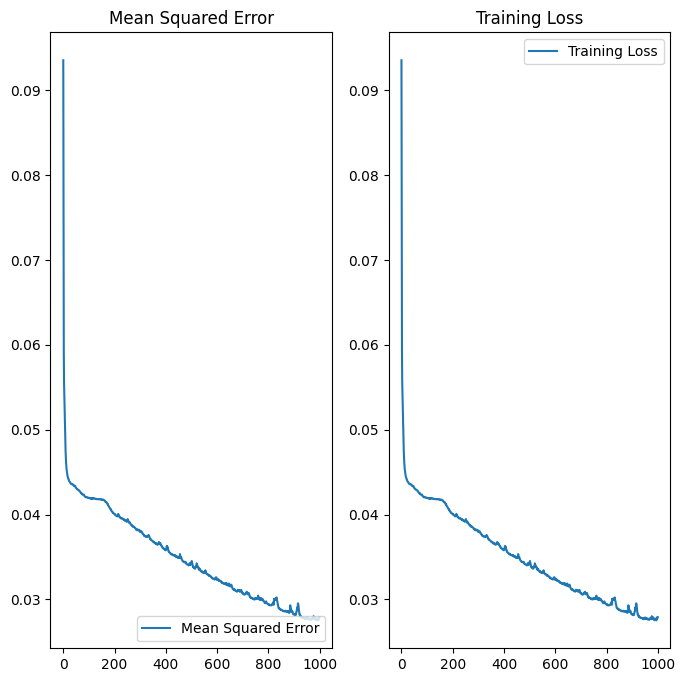

In [7]:
# Nachträgliche Diagrammdarstellung der Trainingsfortschritte
acc = history.history['mean_squared_error']
loss = history.history['loss']

epochs_range = range(epochenanzahl)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Mean Squared Error')
plt.legend(loc='lower right')
plt.title('Mean Squared Error')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.legend(loc='upper right')
plt.title('Training Loss')

Aufloesung in DPI: 100.0
1/1 [==============================] - 0s 98ms/step


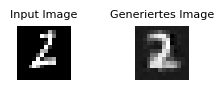

1/1 [==============================] - 0s 16ms/step


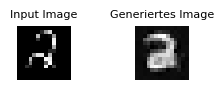

1/1 [==============================] - 0s 17ms/step


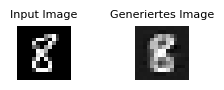

1/1 [==============================] - 0s 15ms/step


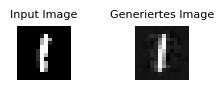

1/1 [==============================] - 0s 15ms/step


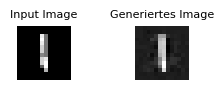

1/1 [==============================] - 0s 17ms/step


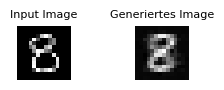

1/1 [==============================] - 0s 28ms/step


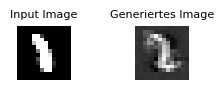

1/1 [==============================] - 0s 16ms/step


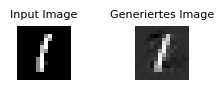

1/1 [==============================] - 0s 16ms/step


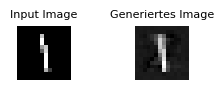

1/1 [==============================] - 0s 17ms/step


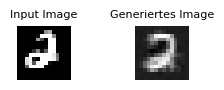

1/1 [==============================] - 0s 16ms/step


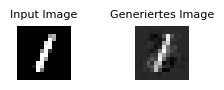

1/1 [==============================] - 0s 24ms/step


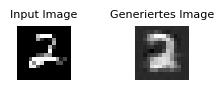

1/1 [==============================] - 0s 21ms/step


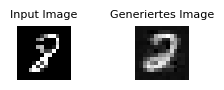

1/1 [==============================] - 0s 18ms/step


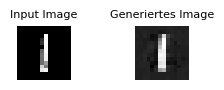

1/1 [==============================] - 0s 14ms/step


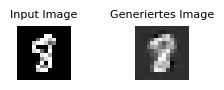

1/1 [==============================] - 0s 15ms/step


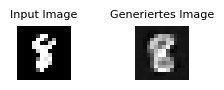

1/1 [==============================] - 0s 26ms/step


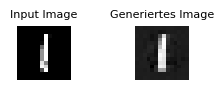

1/1 [==============================] - 0s 15ms/step


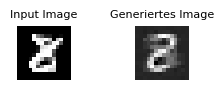

1/1 [==============================] - 0s 16ms/step


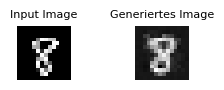

1/1 [==============================] - 0s 16ms/step


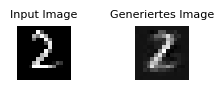

In [8]:
dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

bilderzahl = 20

for i in range(0,bilderzahl):
    #x_reconst = reg.predict(X_test[i].reshape(-1,196))
    x_reconst = model.predict(X_test[i].reshape(-1,196))
    plt.figure(figsize=(280 / float(dpi), 70 / float(dpi)))
    plt.subplot(1,2,1)
    plt.axis('off')
    plt.imshow(X_test[i].reshape(14,14), 'gray')
    plt.title('Input Image', fontsize = 8)
    plt.subplot(1,2,2)
    plt.axis('off')
    plt.imshow(x_reconst.reshape(14,14), 'gray')
    plt.title('Generiertes Image', fontsize = 8)
    plt.show()

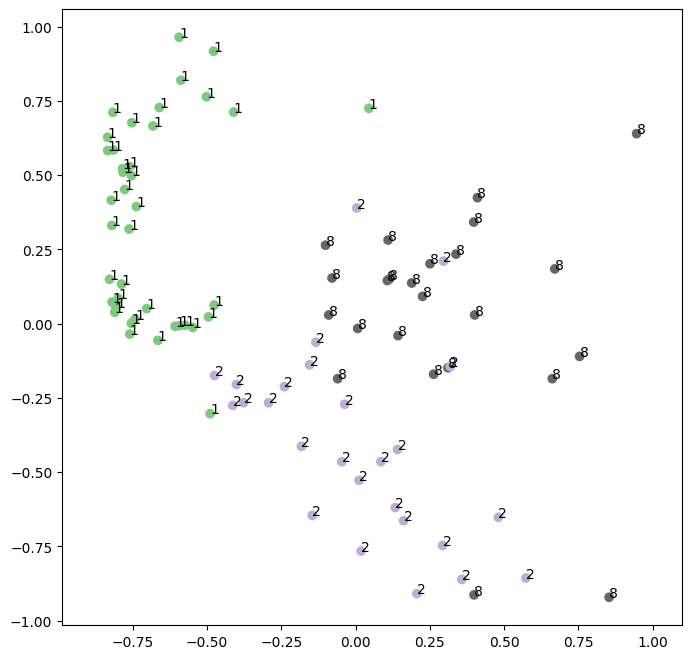

In [9]:
# Darstellung 'Latent Space': Für den gesamten X_test-Datensatz das neuronale Netz Schicht für Schicht
# bis zum Bottleneck berechnen und zu jedem Bild die Outputs der beiden Neuronen als Plot darstellen

first_layer_weights = model.layers[0].get_weights()[0]
first_layer_biases  = model.layers[0].get_weights()[1]
second_layer_weights = model.layers[1].get_weights()[0]
second_layer_biases  = model.layers[1].get_weights()[1]
bottleneck_layer_weights = model.layers[2].get_weights()[0]
bottleneck_layer_biases  = model.layers[2].get_weights()[1]

data = np.asmatrix(X_test)
encoder1 = data*first_layer_weights + first_layer_biases
encoder1 = (np.exp(encoder1) - np.exp(-encoder1))/(np.exp(encoder1) + np.exp(-encoder1))

encoder2 = encoder1*second_layer_weights + second_layer_biases
encoder2 = (np.exp(encoder2) - np.exp(-encoder2))/(np.exp(encoder2) + np.exp(-encoder2))
    
latent = encoder2*bottleneck_layer_weights + bottleneck_layer_biases
latent = (np.exp(latent) - np.exp(-latent))/(np.exp(latent) + np.exp(-latent))

test_latent = np.asarray(latent)
latent_x_y = np.insert(test_latent, 2, y_test, axis = 1)

plt.figure(figsize = (8,8))
plt.scatter(latent_x_y[:,0],latent_x_y[:,1], c = latent_x_y[:,2], cmap = 'Accent')
plt.axis('equal')

for i, txt in enumerate(latent_x_y[:,2]):
    plt.annotate(np.uint8(txt), (latent_x_y[i,0], latent_x_y[i,1]))

plt.show()

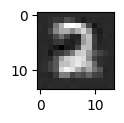

In [11]:
# Neue Bilder erzeugen: im 'Latent Space den Output der beiden Bottleneck-Neuronen willkürlich'
# erzeugen und die Decoderneuronen damit durchrechnen. 

third_layer_weights = model.layers[3].get_weights()[0]
third_layer_biases  = model.layers[3].get_weights()[1]
forth_layer_weights = model.layers[4].get_weights()[0]
forth_layer_biases  = model.layers[4].get_weights()[1]
fifth_layer_weights = model.layers[5].get_weights()[0]
fifth_layer_biases  = model.layers[5].get_weights()[1]

new_data = np.asmatrix([0.0, -0.5])
decoder3 = new_data*third_layer_weights + third_layer_biases

# Tangens-Hyperbolicus-Funktion: Anhand der Gewichtungen wird der Wert der Aktivierungsfunktion für Layer 3 berechnet.
decoder3 = (np.exp(decoder3) - np.exp(-decoder3))/(np.exp(decoder3) + np.exp(-decoder3))

# Tangens-Hyperbolicus-Funktion: Anhand der Gewichtungen wird der Wert der Aktivierungsfunktion für Layer 4 berechnet.
decoder4 = decoder3*forth_layer_weights + forth_layer_biases
decoder4 = (np.exp(decoder4) - np.exp(-decoder4))/(np.exp(decoder4) + np.exp(-decoder4))

reconst = decoder4*fifth_layer_weights + fifth_layer_biases
reconst = (np.exp(reconst) - np.exp(-reconst))/(np.exp(reconst) + np.exp(-reconst))

reconst = np.asarray(reconst)

testbild = reconst.reshape(14,14)
plt.figure(figsize = (1,1))
plt.imshow(testbild, cmap='gray', aspect=1)
plt.show()